### Random Lasso

In [3]:
# Importing the necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, Lasso
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from sklearn.utils import resample

In [4]:

# Load the dataset
data = pd.read_csv("METABRIC_RNA_Mutation.csv")  # Update with the correct file path

# Preprocess the data (drop missing values or handle them accordingly)
data = data.dropna()

# Assuming 'data' is your DataFrame
data1 = pd.get_dummies(data, drop_first=True)
data1=data1.head(200)

C:\Users\ebaah\AppData\Local\Temp\ipykernel_25880\784145300.py:2: DtypeWarning: Columns (678,688,690,692) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("METABRIC_RNA_Mutation.csv")  # Update with the correct file path


In [5]:

# Split the dataset into features (X) and target (y)
X = data1.drop(columns=['overall_survival', 'patient_id', 'overall_survival_months']) 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y = data1['overall_survival_months']  # Target variable

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [6]:

# Apply Lasso with cross-validation to find the optimal alpha (lambda)
lasso_cv = LassoCV(cv=5, random_state=42).fit(X_train, y_train)

# Predict on the test set
y_pred = lasso_cv.predict(X_test)

# Calculate test MSE
test_mse = mean_squared_error(y_test, y_pred)
print(f"Test MSE: {test_mse}")

# Report non-zero coefficients
non_zero_coef = pd.Series(lasso_cv.coef_, index=X.columns)
print("Non-zero coefficients:")
print(non_zero_coef[non_zero_coef != 0])

# Optimal alpha (lambda)
print(f"Optimal lambda: {lasso_cv.alpha_}")


c:\Users\ebaah\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.199e+01, tolerance: 3.482e+01
  model = cd_fast.enet_coordinate_descent(
c:\Users\ebaah\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.487e+01, tolerance: 3.482e+01
  model = cd_fast.enet_coordinate_descent(
c:\Users\ebaah\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regula

Test MSE: 4074.247741398339
Non-zero coefficients:
age_at_diagnosis                -0.611377
lymph_nodes_examined_positive   -0.862717
hsd17b4                          0.772159
dtype: float64
Optimal lambda: 12.935839844339387


In [7]:
X_train.shape

(160, 5105)

In [9]:
X.shape

(200, 5105)

In [8]:
# Function to perform Random Lasso using bootstrap and cross-validation for lambda
def random_lasso_cv(X_train, y_train, n_bootstraps=100, subset_size=0.7, cv=5):
    coef_matrix = []
    alpha_matrix = []
    
    for i in range(n_bootstraps):
        # Bootstrap sampling
        X_sample, y_sample = resample(X_train, y_train, n_samples=int(subset_size * X_train.shape[0]), random_state=i)
        
        # Apply LassoCV to the bootstrap sample
        lasso_cv = LassoCV(cv=cv, random_state=i).fit(X_sample, y_sample)
        
        # Collect the coefficients and the optimal alpha (lambda)
        coef_matrix.append(lasso_cv.coef_)
        alpha_matrix.append(lasso_cv.alpha_)
    
    # Average the coefficients and the lambda values across all bootstraps
    avg_coefs = np.mean(coef_matrix, axis=0)
    avg_alpha = np.mean(alpha_matrix)
    
    return avg_coefs, avg_alpha

# Perform Random Lasso with cross-validation
n_bootstraps = 100
subset_size = 0.7

avg_coefs, avg_alpha = random_lasso_cv(X_train, y_train, n_bootstraps=n_bootstraps, subset_size=subset_size)

# Report non-zero coefficients
non_zero_coefs = pd.Series(avg_coefs, index=X.columns)
non_zero_coefs = non_zero_coefs[non_zero_coefs != 0]

print("Non-zero coefficients from Random Lasso:")
print(non_zero_coefs)

# Report the average lambda (alpha) used across the bootstraps
print(f"Average lambda (alpha) across bootstraps: {avg_alpha}")

# Now, evaluate the performance on the test set using Lasso with the average alpha
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=avg_alpha)
lasso.fit(X_train, y_train)

# Predict on the test set
y_pred = lasso.predict(X_test)

# Calculate the test MSE
test_mse = mean_squared_error(y_test, y_pred)
print(f"Test MSE: {test_mse}")

KeyboardInterrupt: 

In [109]:
non_zero_coefs

age_at_diagnosis                 -0.607983
neoplasm_histologic_grade        -0.010868
lymph_nodes_examined_positive    -0.806991
mutation_count                    0.104941
nottingham_prognostic_index       0.073041
                                    ...   
ugt2b15                          -0.317281
ugt2b17                          -0.041504
ugt2b7                            0.501483
primary_tumor_laterality_Right    0.086422
death_from_cancer_Living          3.001552
Length: 438, dtype: float64

In [110]:
data1.shape

(200, 5108)

In [111]:
non_zero_coefs
feature_importance = pd.DataFrame(non_zero_coefs)
feature_importance = feature_importance.reset_index()
feature_importance.columns = ['Features','Variable Importance']
sorted_feature_importance = feature_importance.sort_values(by='Variable Importance', ascending=False)


In [112]:
#sorted_feature_importance

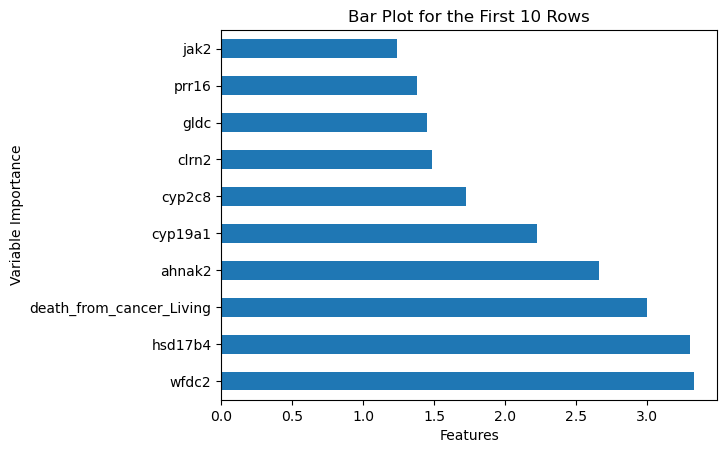

In [113]:
import matplotlib.pyplot as plt

# Bar plot for the first 10 rows
sorted_feature_importance.head(10).plot(kind='barh', x='Features', y='Variable Importance', legend=False)

# Adding labels and title
plt.xlabel('Features')
plt.ylabel('Variable Importance')
plt.title('Bar Plot for the First 10 Rows')

# Show plot
plt.show()

From the above results, we observe that under high-dimensional situation, the randon lasso outperforms the traditional lasso in terms of prediction accuracy. The test MSE for Random Lasso is 3869.97 compared with 4074.25 for the traditional Lasso. 

Also, it include more features than the number of observations which traditional Lasso can't do.